# 231. How much of the Swiss-Prot result is transmembrane segments?

The midi-plus report scores every arm on two truth sets. On Pfam the label is a family;
on Swiss-Prot it is a feature type (TRANSMEM, DOMAIN, BINDING, ...). A human TRANSMEM
helix matching any E. coli TRANSMEM helix in a 4-letter polarity alphabet is a true
positive with no homology involved. The same engine on the same queries scores 0.000
(E. coli, Pfam) and 0.127 (E. coli, Swiss-Prot); the only thing that changed is whether
the label is a family. This notebook asks whether the Swiss-Prot result survives once the
features a hydrophobicity scan could reproduce are taken out, and puts a scan with no
search in it on the same leaderboard.

Inputs: the pipeline's own per-call tables for the Swiss-Prot truth set (midi-plus run,
998 chr6/MHC-region queries, 9 target proteomes, every kmerseek arm and every comparison
tool, `dedup_transfers=True` as in the report's headline), re-scored by
`scripts/rescore_swissprot_subsets.py` with the pipeline's own Fmax
(`cafa_metrics.protein_centric_curve`, pinned at olgabot/all-qfo-report e136731). The
re-score reproduces the report's numbers to the last digit on the full truth set.

Subsets of the truth set:

| subset | feature types | what it measures |
|---|---|---|
| all | every type (14) | the report's headline |
| composition | TRANSMEM, INTRAMEM, COILED, REGION, REPEAT | features reproducible from composition or periodicity alone |
| heldout | DOMAIN, ZN_FING, DNA_BIND, MOTIF, BINDING, ACT_SITE, SITE | family- and site-bearing features |
| domain_only | DOMAIN, ZN_FING, DNA_BIND, MOTIF | range features that name a family, no point features |
| transmem | TRANSMEM | the one type the alphabet question turns on |

Held-out semantics: truth cut to the subset's types, calls kept only on proteins that
still have truth and only with labels in the subset, true positives re-judged against the
cut (`evaluate_domain_calls.restrict_tp_to_cut`). That is what the benchmark would have
said had the other feature types never been annotated.

Two no-search control arms, computed from the human query sequence alone and labelled
TRANSMEM (`notebooks/swissprot_control_utils.py`):

* Kyte-Doolittle 1982 hydropathy, 19-residue window, mean above 1.6.
* Exact runs of kmerseek's own hydrophobic class (Thomas-Dill), 15 residues with up to
  2 polar residues inside, and 12 residues with none.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

FIG = Path("../figures")
DATA = Path("/Users/olga/data/qfo-pfam-region-midi-plus")
SP9 = [
    "mouse",
    "chicken",
    "zebrafish",
    "ciona",
    "fly",
    "worm",
    "yeast",
    "arabidopsis",
    "ecoli",
]
SUBSETS = ["all", "composition", "heldout", "domain_only", "transmem"]
SUBSET_LABEL = {
    "all": "all features",
    "composition": "composition\n(TM, coiled, region, repeat)",
    "heldout": "held out\n(family + site features)",
    "domain_only": "domain-naming\nrange features",
    "transmem": "TRANSMEM only",
}
TOOL_LABEL = {
    "kmerseek": "kmerseek",
    "hhblits": "HHblits",
    "hmmer3_phmmer": "phmmer",
    "hmmer3_jackhmmer": "jackhmmer",
    "mmseqs2_seqseq": "MMseqs2",
    "mmseqs2_iterative": "MMseqs2 iter.",
    "foldseek": "Foldseek",
    "reseek": "Reseek",
    "prostt5": "ProstT5",
    "folddisco": "Folddisco",
    "control": "no-search control",
}
TOOL_COLOR = {
    "kmerseek": "#a50f15",
    "hhblits": "#1f77b4",
    "hmmer3_phmmer": "#6baed6",
    "hmmer3_jackhmmer": "#9ecae1",
    "mmseqs2_seqseq": "#bcbddc",
    "mmseqs2_iterative": "#756bb1",
    "foldseek": "#2ca02c",
    "reseek": "#98df8a",
    "prostt5": "#8c564b",
    "folddisco": "#7f7f7f",
    "control": "#ff7f0e",
}

d = pl.read_parquet(DATA / "231_swissprot_subset_fmax.parquet")
d = d.filter(pl.col("species").is_in(SP9) | (pl.col("tool") == "control"))
d = d.with_columns(pl.col("subset").cast(pl.Enum(SUBSETS)))
controls = d.filter(pl.col("tool") == "control")
runs = d.filter(pl.col("tool") != "control")

mean = runs.group_by("tool", "arm", "variant", "subset").agg(
    pl.col("fmax").mean(),
    pl.col("fmax").min().alias("fmax_min"),
    pl.col("fmax").max().alias("fmax_max"),
    pl.len().alias("n_species"),
)
assert (mean["n_species"] == 9).all()
best = mean.sort("fmax", descending=True).group_by("tool", "subset").first()

print(
    f"{runs['arm'].n_unique()} arms x {runs['species'].n_unique()} species; kmerseek arms: {runs.filter(pl.col('tool') == 'kmerseek')['arm'].n_unique()}"
)
print("Truth instances per subset (human query set):")
print(
    runs.filter(
        (pl.col("species") == "mouse") & (pl.col("arm") == "hmmer3_phmmer.default")
    )
    .select("subset", "n_truth", "n_truth_proteins")
    .sort("subset")
)

415 arms x 9 species; kmerseek arms: 406
Truth instances per subset (human query set):
shape: (5, 3)
┌─────────────┬─────────┬──────────────────┐
│ subset      ┆ n_truth ┆ n_truth_proteins │
│ ---         ┆ ---     ┆ ---              │
│ enum        ┆ i64     ┆ i64              │
╞═════════════╪═════════╪══════════════════╡
│ all         ┆ 7185    ┆ 933              │
│ composition ┆ 3716    ┆ 810              │
│ heldout     ┆ 3469    ┆ 661              │
│ domain_only ┆ 1667    ┆ 555              │
│ transmem    ┆ 1124    ┆ 305              │
└─────────────┴─────────┴──────────────────┘


## 1. Leaderboard by subset

Each tool at its best arm for that subset (kmerseek's best alphabet and k are chosen per
subset, so this is the most favourable reading kmerseek can get), mean Fmax over the nine
target proteomes, range across proteomes as the bar. The rank column is the number the
report's leaderboard shows.

shape: (10, 6)
┌───────────────────┬─────┬─────────────┬─────────┬─────────────┬──────────┐
│ tool              ┆ all ┆ composition ┆ heldout ┆ domain_only ┆ transmem │
│ ---               ┆ --- ┆ ---         ┆ ---     ┆ ---         ┆ ---      │
│ str               ┆ u32 ┆ u32         ┆ u32     ┆ u32         ┆ u32      │
╞═══════════════════╪═════╪═════════════╪═════════╪═════════════╪══════════╡
│ folddisco         ┆ 1   ┆ 1           ┆ 1       ┆ 1           ┆ 1        │
│ hhblits           ┆ 2   ┆ 2           ┆ 2       ┆ 2           ┆ 3        │
│ kmerseek          ┆ 3   ┆ 3           ┆ 10      ┆ 10          ┆ 2        │
│ hmmer3_phmmer     ┆ 4   ┆ 6           ┆ 6       ┆ 6           ┆ 6        │
│ foldseek          ┆ 5   ┆ 7           ┆ 3       ┆ 3           ┆ 9        │
│ hmmer3_jackhmmer  ┆ 6   ┆ 5           ┆ 8       ┆ 8           ┆ 5        │
│ mmseqs2_iterative ┆ 7   ┆ 9           ┆ 4       ┆ 4           ┆ 8        │
│ mmseqs2_seqseq    ┆ 8   ┆ 10          ┆ 5       ┆ 5        

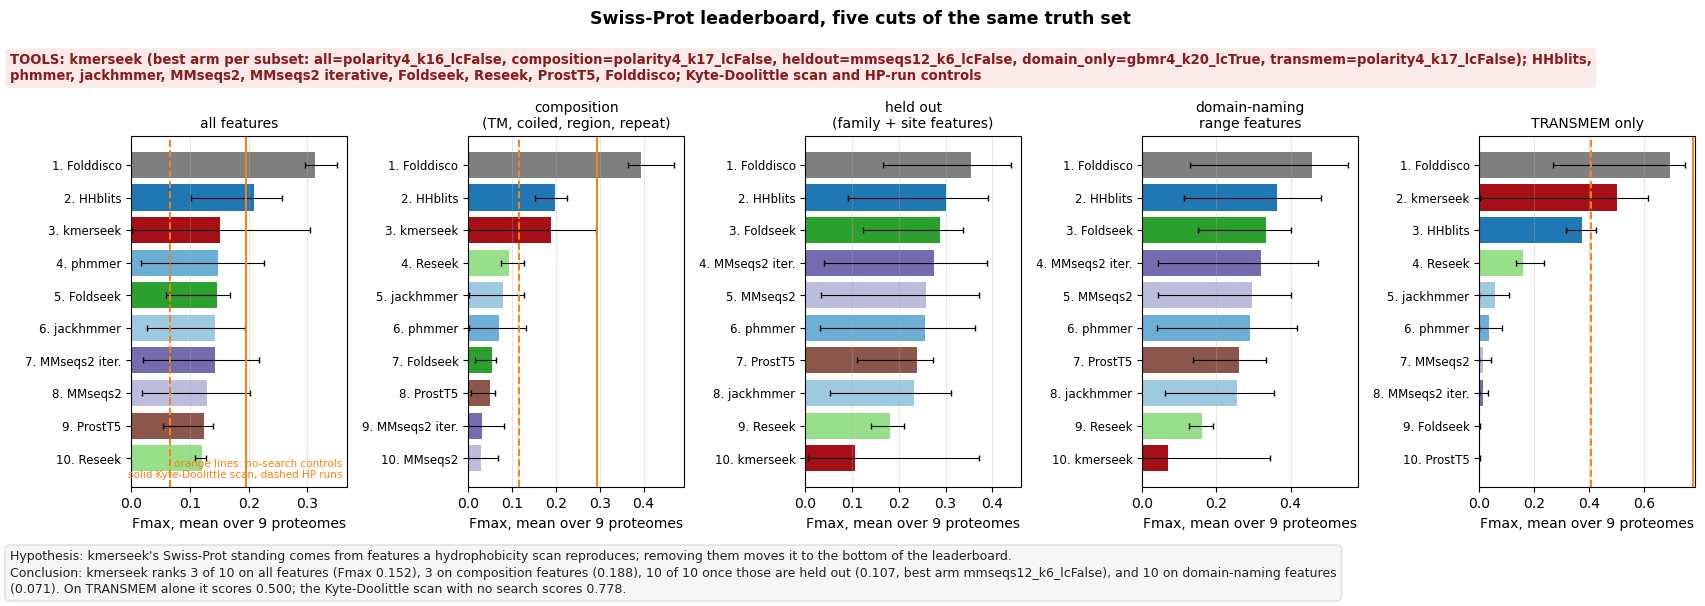

In [2]:
lb = best.sort("subset", "fmax", descending=[False, True]).with_columns(
    pl.col("fmax").rank(method="ordinal", descending=True).over("subset").alias("rank")
)
tools_order = lb.filter(pl.col("subset") == "all").sort("rank")["tool"].to_list()

fig, axes = plt.subplots(1, len(SUBSETS), figsize=(17, 4.6), sharey=False)
for ax, s in zip(axes, SUBSETS):
    t = lb.filter(pl.col("subset") == s).sort("rank")
    y = np.arange(t.height)
    ax.barh(
        y,
        t["fmax"],
        xerr=[t["fmax"] - t["fmax_min"], t["fmax_max"] - t["fmax"]],
        color=[TOOL_COLOR[x] for x in t["tool"]],
        capsize=2,
        error_kw=dict(lw=0.8),
    )
    ax.set_yticks(
        y, [f"{r}. {TOOL_LABEL[x]}" for r, x in zip(t["rank"], t["tool"])], fontsize=8.5
    )
    ax.invert_yaxis()
    ax.set_title(SUBSET_LABEL[s], fontsize=10)
    ax.set_xlabel("Fmax, mean over 9 proteomes")
    ax.grid(axis="x", alpha=0.3)
    for ctrl, ls in [
        ("control.kyte_doolittle_w19_1.6", "-"),
        ("control.hp_thomas_dill_run15_p2", "--"),
    ]:
        v = controls.filter((pl.col("arm") == ctrl) & (pl.col("subset") == s))["fmax"][
            0
        ]
        if v > 0:
            ax.axvline(v, color=TOOL_COLOR["control"], ls=ls, lw=1.4)
axes[0].text(
    0.98,
    0.02,
    "orange lines: no-search controls\nsolid Kyte-Doolittle scan, dashed HP runs",
    transform=axes[0].transAxes,
    ha="right",
    va="bottom",
    fontsize=7.5,
    color=TOOL_COLOR["control"],
)

show = lb.select(
    "subset",
    "rank",
    "tool",
    "arm",
    pl.col("fmax").round(3),
    pl.col("fmax_min").round(3),
    pl.col("fmax_max").round(3),
)
print(show.pivot(on="subset", index="tool", values="rank").sort("all"))
print(
    show.pivot(on="subset", index=["tool"], values="fmax").sort("all", descending=True)
)

km = lb.filter(pl.col("tool") == "kmerseek").sort("subset")
kr = {s: int(km.filter(pl.col("subset") == s)["rank"][0]) for s in SUBSETS}
kf = {s: km.filter(pl.col("subset") == s)["fmax"][0] for s in SUBSETS}
ka = {
    s: km.filter(pl.col("subset") == s)["arm"][0].replace("kmerseek.", "")
    for s in SUBSETS
}
n_tools = lb["tool"].n_unique()
hc.finish_figure(
    fig,
    FIG / "231_leaderboard_by_subset.png",
    tools=f"kmerseek (best arm per subset: {', '.join(f'{s}={ka[s]}' for s in SUBSETS)}); HHblits, phmmer, jackhmmer, MMseqs2, MMseqs2 iterative, Foldseek, Reseek, ProstT5, Folddisco; Kyte-Doolittle scan and HP-run controls",
    hypothesis="kmerseek's Swiss-Prot standing comes from features a hydrophobicity scan reproduces; removing them moves it to the bottom of the leaderboard.",
    conclusion=(
        f"kmerseek ranks {kr['all']} of {n_tools} on all features (Fmax {kf['all']:.3f}), {kr['composition']} on composition features ({kf['composition']:.3f}), "
        f"{kr['heldout']} of {n_tools} once those are held out ({kf['heldout']:.3f}, best arm {ka['heldout']}), and {kr['domain_only']} on domain-naming features ({kf['domain_only']:.3f}). "
        f"On TRANSMEM alone it scores {kf['transmem']:.3f}; the Kyte-Doolittle scan with no search scores {controls.filter((pl.col('arm') == 'control.kyte_doolittle_w19_1.6') & (pl.col('subset') == 'transmem'))['fmax'][0]:.3f}."
    ),
    title="Swiss-Prot leaderboard, five cuts of the same truth set",
)

## 2. The no-search controls against every kmerseek arm

The controls see only the human query sequence and label TRANSMEM. They cannot score on
the held-out subset at all. On the full truth set, where the report's headline lives,
the question is where they land relative to the 406 kmerseek arms and to the comparison
tools.

kmerseek arms above the Kyte-Doolittle scan on all features: 0 of 406
shape: (5, 2)
┌───────────────────────┬───────┐
│ variant               ┆ fmax  │
│ ---                   ┆ ---   │
│ str                   ┆ f64   │
╞═══════════════════════╪═══════╡
│ polarity4_k16_lcFalse ┆ 0.152 │
│ polarity4_k16_lcTrue  ┆ 0.151 │
│ polarity4_k17_lcFalse ┆ 0.149 │
│ polarity4_k17_lcTrue  ┆ 0.149 │
│ polarity4_k15_lcFalse ┆ 0.144 │
└───────────────────────┴───────┘
shape: (15, 5)
┌─────────────────────────────────┬─────────────┬───────┬────────────────┬─────────────┐
│ arm                             ┆ subset      ┆ fmax  ┆ fmax_precision ┆ fmax_recall │
│ ---                             ┆ ---         ┆ ---   ┆ ---            ┆ ---         │
│ str                             ┆ enum        ┆ f64   ┆ f64            ┆ f64         │
╞═════════════════════════════════╪═════════════╪═══════╪════════════════╪═════════════╡
│ control.hp_thomas_dill_run12_p… ┆ all         ┆ 0.024 ┆ 0.615          ┆ 0.012  

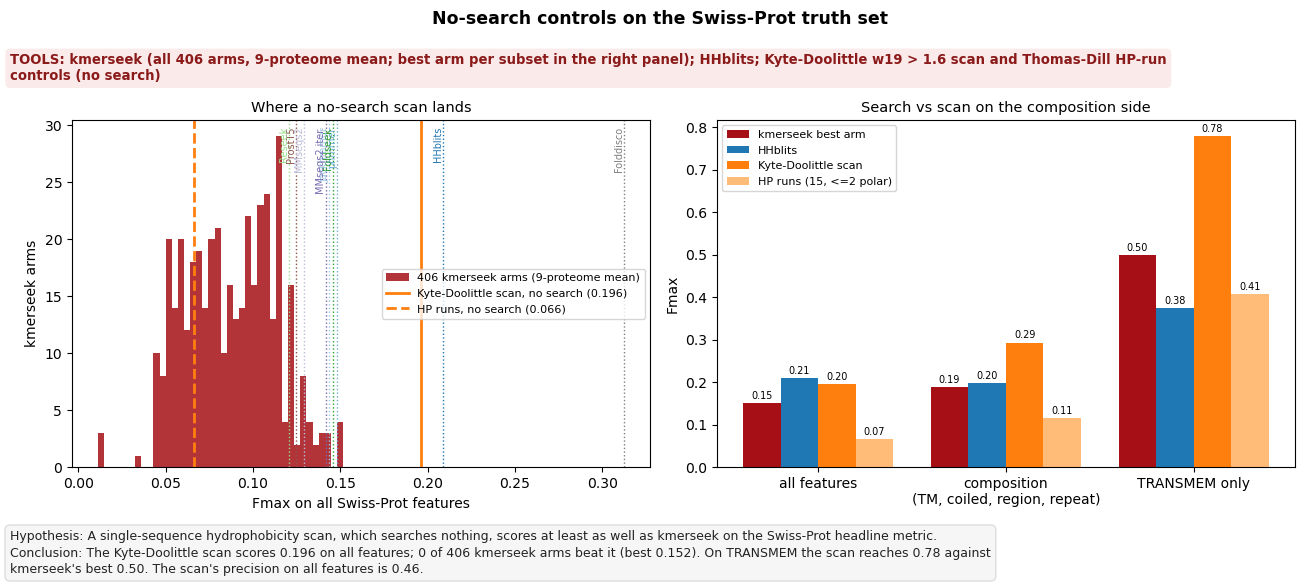

In [3]:
km_all = mean.filter((pl.col("tool") == "kmerseek") & (pl.col("subset") == "all")).sort(
    "fmax", descending=True
)
kd_all = controls.filter(
    (pl.col("arm") == "control.kyte_doolittle_w19_1.6") & (pl.col("subset") == "all")
)["fmax"][0]
hp_all = controls.filter(
    (pl.col("arm") == "control.hp_thomas_dill_run15_p2") & (pl.col("subset") == "all")
)["fmax"][0]
n_above = int((km_all["fmax"] > kd_all).sum())
base_all = mean.filter(
    (pl.col("tool") != "kmerseek") & (pl.col("subset") == "all")
).sort("fmax", descending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
alpha_of = km_all["variant"].str.extract(r"^(.+)_k\d+", 1)
ax.hist(
    km_all["fmax"],
    bins=40,
    color=TOOL_COLOR["kmerseek"],
    alpha=0.85,
    label="406 kmerseek arms (9-proteome mean)",
)
ax.axvline(
    kd_all,
    color=TOOL_COLOR["control"],
    lw=2,
    label=f"Kyte-Doolittle scan, no search ({kd_all:.3f})",
)
ax.axvline(
    hp_all,
    color=TOOL_COLOR["control"],
    lw=2,
    ls="--",
    label=f"HP runs, no search ({hp_all:.3f})",
)
for r in base_all.iter_rows(named=True):
    ax.axvline(r["fmax"], color=TOOL_COLOR[r["tool"]], lw=1, ls=":")
    ax.text(
        r["fmax"],
        ax.get_ylim()[1] * 0.98,
        TOOL_LABEL[r["tool"]],
        rotation=90,
        va="top",
        ha="right",
        fontsize=7,
        color=TOOL_COLOR[r["tool"]],
    )
ax.set_xlabel("Fmax on all Swiss-Prot features")
ax.set_ylabel("kmerseek arms")
ax.legend(fontsize=8, loc="center right")
ax.set_title("Where a no-search scan lands", fontsize=10.5)

ax = axes[1]
sub = ["all", "composition", "transmem"]
x = np.arange(len(sub))
w = 0.2
series = [
    (
        "kmerseek best arm",
        [
            best.filter((pl.col("tool") == "kmerseek") & (pl.col("subset") == s))[
                "fmax"
            ][0]
            for s in sub
        ],
        TOOL_COLOR["kmerseek"],
    ),
    (
        "HHblits",
        [
            best.filter((pl.col("tool") == "hhblits") & (pl.col("subset") == s))[
                "fmax"
            ][0]
            for s in sub
        ],
        TOOL_COLOR["hhblits"],
    ),
    (
        "Kyte-Doolittle scan",
        [
            controls.filter(
                (pl.col("arm") == "control.kyte_doolittle_w19_1.6")
                & (pl.col("subset") == s)
            )["fmax"][0]
            for s in sub
        ],
        TOOL_COLOR["control"],
    ),
    (
        "HP runs (15, <=2 polar)",
        [
            controls.filter(
                (pl.col("arm") == "control.hp_thomas_dill_run15_p2")
                & (pl.col("subset") == s)
            )["fmax"][0]
            for s in sub
        ],
        "#ffbb78",
    ),
]
for i, (lab, vals, col) in enumerate(series):
    ax.bar(x + (i - 1.5) * w, vals, w, color=col, label=lab)
    for xi, v in zip(x + (i - 1.5) * w, vals):
        ax.text(xi, v + 0.01, f"{v:.2f}", ha="center", fontsize=7)
ax.set_xticks(x, [SUBSET_LABEL[s] for s in sub])
ax.set_ylabel("Fmax")
ax.legend(fontsize=8)
ax.set_title("Search vs scan on the composition side", fontsize=10.5)

print(
    f"kmerseek arms above the Kyte-Doolittle scan on all features: {n_above} of {km_all.height}"
)
print(km_all.head(5).select("variant", pl.col("fmax").round(3)))
print(
    controls.select(
        "arm",
        "subset",
        pl.col("fmax").round(3),
        pl.col("fmax_precision").round(3),
        pl.col("fmax_recall").round(3),
    ).sort("arm", "subset")
)
hc.finish_figure(
    fig,
    FIG / "231_controls_vs_kmerseek.png",
    tools="kmerseek (all 406 arms, 9-proteome mean; best arm per subset in the right panel); HHblits; Kyte-Doolittle w19 > 1.6 scan and Thomas-Dill HP-run controls (no search)",
    hypothesis="A single-sequence hydrophobicity scan, which searches nothing, scores at least as well as kmerseek on the Swiss-Prot headline metric.",
    conclusion=(
        f"The Kyte-Doolittle scan scores {kd_all:.3f} on all features; {n_above} of {km_all.height} kmerseek arms beat it (best {km_all['fmax'][0]:.3f}). "
        f"On TRANSMEM the scan reaches {controls.filter((pl.col('arm') == 'control.kyte_doolittle_w19_1.6') & (pl.col('subset') == 'transmem'))['fmax'][0]:.2f} against kmerseek's best {best.filter((pl.col('tool') == 'kmerseek') & (pl.col('subset') == 'transmem'))['fmax'][0]:.2f}. "
        f"The scan's precision on all features is {controls.filter((pl.col('arm') == 'control.kyte_doolittle_w19_1.6') & (pl.col('subset') == 'all'))['fmax_precision'][0]:.2f}."
    ),
    title="No-search controls on the Swiss-Prot truth set",
)

## 3. Where each tool's true positives come from

Share of true-positive calls by feature type, pooled over the nine proteomes, for the
comparison tools and four kmerseek arms: the report's headline (polarity4 k17), the two
designated 2-letter arms (hp_thomas_dill2 k23, hp_pbotc_1st_ed2 k19) and protein20 k5.
Read from the per-call tables directly.

shape: (10, 13)
┌─────────────────────────────────┬─────────┬──────────┬───────┬────────┬──────────┬─────────┬──────────┬───────┬──────────┬────────┬────────┬────────┐
│ arm                             ┆ BINDING ┆ INTRAMEM ┆ SITE  ┆ REGION ┆ ACT_SITE ┆ ZN_FING ┆ TRANSMEM ┆ MOTIF ┆ DNA_BIND ┆ COILED ┆ REPEAT ┆ DOMAIN │
│ ---                             ┆ ---     ┆ ---      ┆ ---   ┆ ---    ┆ ---      ┆ ---     ┆ ---      ┆ ---   ┆ ---      ┆ ---    ┆ ---    ┆ ---    │
│ str                             ┆ f64     ┆ f64      ┆ f64   ┆ f64    ┆ f64      ┆ f64     ┆ f64      ┆ f64   ┆ f64      ┆ f64    ┆ f64    ┆ f64    │
╞═════════════════════════════════╪═════════╪══════════╪═══════╪════════╪══════════╪═════════╪══════════╪═══════╪══════════╪════════╪════════╪════════╡
│ foldseek.3di_aa                 ┆ 0.293   ┆ 0.0      ┆ 0.023 ┆ 0.155  ┆ 0.096    ┆ 0.026   ┆ 0.0      ┆ 0.0   ┆ 0.009    ┆ 0.008  ┆ 0.002  ┆ 0.388  │
│ hmmer3_phmmer.default           ┆ 0.193   ┆ 0.001    ┆ 0.012 ┆ 0.143  

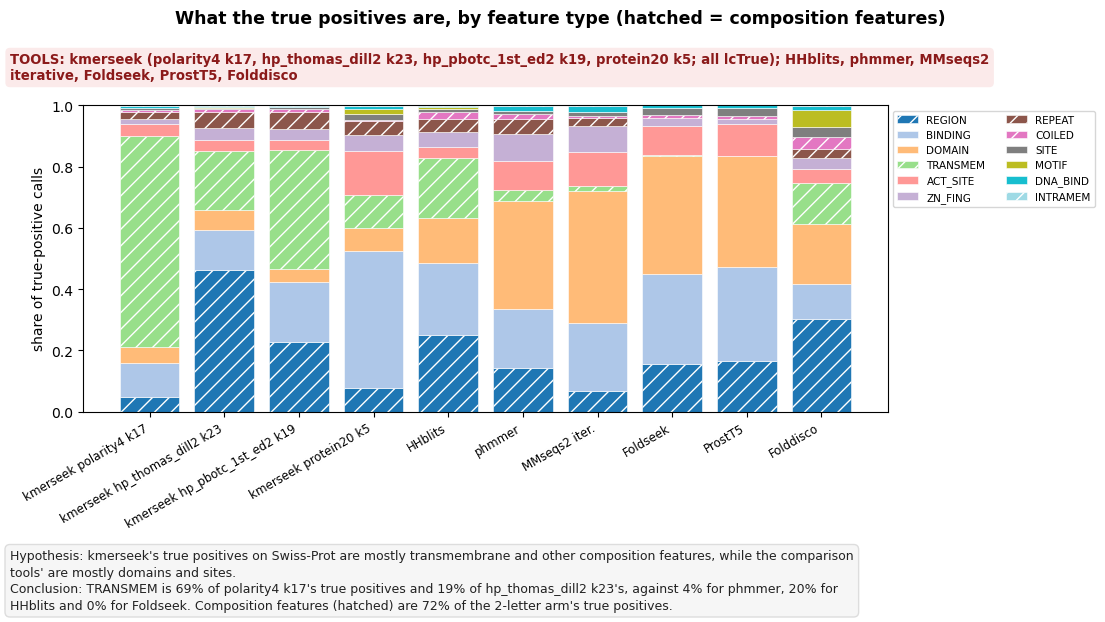

In [4]:
FOCUS = {
    "kmerseek.polarity4_k17_lcTrue": "kmerseek polarity4 k17",
    "kmerseek.hp_thomas_dill2_k23_lcTrue": "kmerseek hp_thomas_dill2 k23",
    "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue": "kmerseek hp_pbotc_1st_ed2 k19",
    "kmerseek.protein20_k5_lcTrue": "kmerseek protein20 k5",
    "hhblits.single_seq": "HHblits",
    "hmmer3_phmmer.default": "phmmer",
    "mmseqs2_iterative.s7": "MMseqs2 iter.",
    "foldseek.3di_aa": "Foldseek",
    "prostt5.3di_from_seq": "ProstT5",
    "folddisco.motif": "Folddisco",
}
rows = []
for arm in FOCUS:
    for sp in SP9:
        p = DATA / "calls_swissprot" / f"swissprot.{arm}.{sp}.dedup.calls.parquet"
        c = pl.read_parquet(p, columns=["pfam_id", "is_tp"])
        rows.append(
            c.filter("is_tp")
            .group_by("pfam_id")
            .len()
            .with_columns(pl.lit(arm).alias("arm"), pl.lit(sp).alias("species"))
        )
tp = pl.concat(rows)
tp_share = (
    tp.group_by("arm", "pfam_id")
    .agg(pl.col("len").sum())
    .with_columns((pl.col("len") / pl.col("len").sum().over("arm")).alias("share"))
)
types = (
    tp_share.group_by("pfam_id")
    .agg(pl.col("len").sum())
    .sort("len", descending=True)["pfam_id"]
    .to_list()
)
comp_types = ["TRANSMEM", "INTRAMEM", "COILED", "REGION", "REPEAT"]
type_color = {t: c for t, c in zip(types, plt.cm.tab20(np.linspace(0, 1, len(types))))}

fig, ax = plt.subplots(figsize=(11, 4.6))
arms = list(FOCUS)
bottom = np.zeros(len(arms))
for t in types:
    vals = np.array(
        [
            tp_share.filter((pl.col("arm") == a) & (pl.col("pfam_id") == t))[
                "share"
            ].sum()
            for a in arms
        ]
    )
    ax.bar(
        np.arange(len(arms)),
        vals,
        bottom=bottom,
        color=type_color[t],
        label=t,
        edgecolor="white",
        lw=0.4,
        hatch="//" if t in comp_types else None,
    )
    bottom += vals
ax.set_xticks(
    np.arange(len(arms)),
    [FOCUS[a] for a in arms],
    rotation=30,
    ha="right",
    fontsize=8.5,
)
ax.set_ylabel("share of true-positive calls")
ax.legend(fontsize=7.5, ncol=2, loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set_ylim(0, 1)

comp_share = (
    tp_share.filter(pl.col("pfam_id").is_in(comp_types))
    .group_by("arm")
    .agg(pl.col("share").sum())
    .sort("share", descending=True)
)
tm_share = (
    tp_share.filter(pl.col("pfam_id") == "TRANSMEM")
    .group_by("arm")
    .agg(pl.col("share").sum())
)
print(
    tp_share.with_columns(pl.col("share").round(3))
    .pivot(on="pfam_id", index="arm", values="share")
    .fill_null(0.0)
)
print(comp_share.with_columns(pl.col("share").round(3)))


def sh(df, a):
    v = df.filter(pl.col("arm") == a)["share"]
    return v[0] if v.len() else 0.0


hc.finish_figure(
    fig,
    FIG / "231_tp_share_by_feature_type.png",
    tools="kmerseek (polarity4 k17, hp_thomas_dill2 k23, hp_pbotc_1st_ed2 k19, protein20 k5; all lcTrue); HHblits, phmmer, MMseqs2 iterative, Foldseek, ProstT5, Folddisco",
    hypothesis="kmerseek's true positives on Swiss-Prot are mostly transmembrane and other composition features, while the comparison tools' are mostly domains and sites.",
    conclusion=(
        f"TRANSMEM is {100 * sh(tm_share, 'kmerseek.polarity4_k17_lcTrue'):.0f}% of polarity4 k17's true positives and {100 * sh(tm_share, 'kmerseek.hp_thomas_dill2_k23_lcTrue'):.0f}% of hp_thomas_dill2 k23's, against "
        f"{100 * sh(tm_share, 'hmmer3_phmmer.default'):.0f}% for phmmer, {100 * sh(tm_share, 'hhblits.single_seq'):.0f}% for HHblits and {100 * sh(tm_share, 'foldseek.3di_aa'):.0f}% for Foldseek. "
        f"Composition features (hatched) are {100 * sh(comp_share, 'kmerseek.hp_thomas_dill2_k23_lcTrue'):.0f}% of the 2-letter arm's true positives."
    ),
    title="What the true positives are, by feature type (hatched = composition features)",
)

## 4. Retention with divergence, composition vs held-out

The report's divergence figure says kmerseek keeps 62% of its mouse Swiss-Prot Fmax at
E. coli (hp_thomas_dill2 k23) while phmmer keeps 30%. On Pfam the same arm keeps 3%. If
the Swiss-Prot retention is a hydrophobicity scan, it should live in the composition
subset and vanish in the held-out one.

shape: (25, 5)
┌─────────────────────────────────┬─────────────┬───────┬───────┬────────────────────────────┐
│ arm                             ┆ subset      ┆ ecoli ┆ mouse ┆ retention_ecoli_over_mouse │
│ ---                             ┆ ---         ┆ ---   ┆ ---   ┆ ---                        │
│ str                             ┆ enum        ┆ f64   ┆ f64   ┆ f64                        │
╞═════════════════════════════════╪═════════════╪═══════╪═══════╪════════════════════════════╡
│ foldseek.3di_aa                 ┆ all         ┆ 0.139 ┆ 0.161 ┆ 0.86                       │
│ hhblits.single_seq              ┆ all         ┆ 0.145 ┆ 0.232 ┆ 0.63                       │
│ hmmer3_phmmer.default           ┆ all         ┆ 0.049 ┆ 0.226 ┆ 0.22                       │
│ kmerseek.hp_thomas_dill2_k23_l… ┆ all         ┆ 0.108 ┆ 0.192 ┆ 0.56                       │
│ kmerseek.polarity4_k17_lcTrue   ┆ all         ┆ 0.143 ┆ 0.328 ┆ 0.44                       │
│ foldseek.3di_aa                 ┆

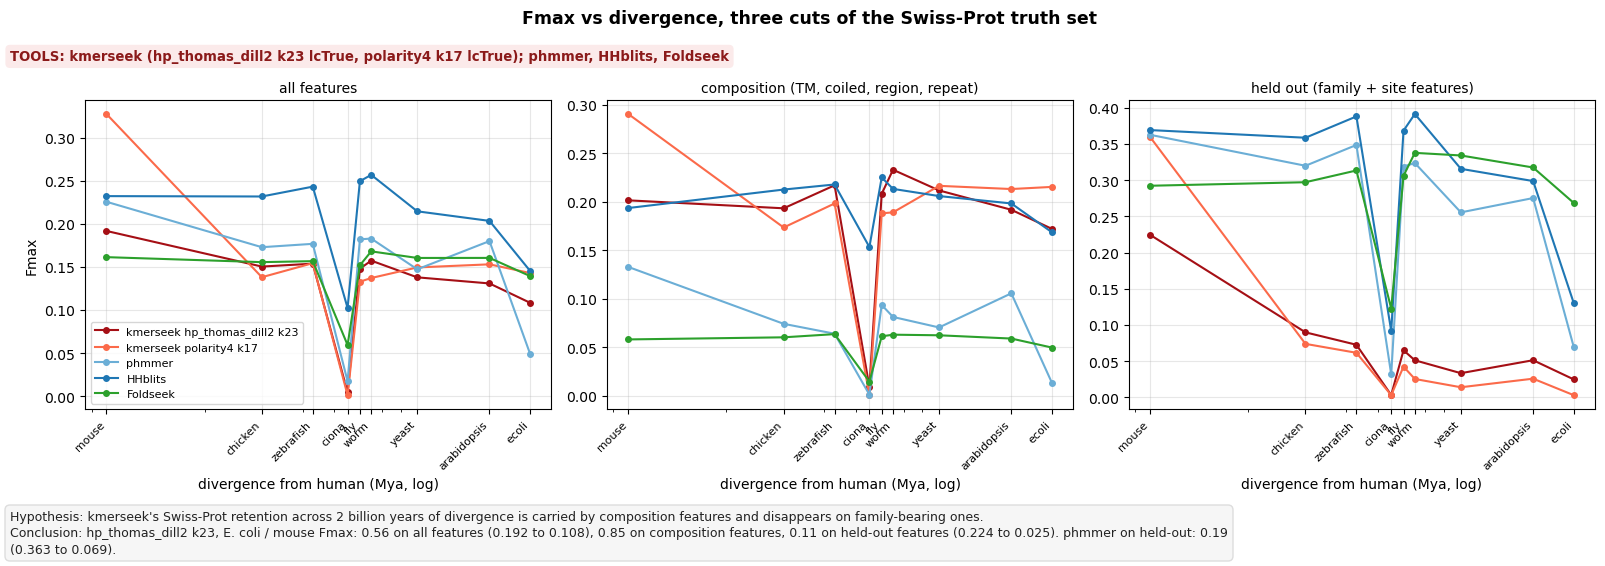

In [5]:
mya = runs.select("species", "species_mya").unique().sort("species_mya")
ARMS4 = {
    "kmerseek.hp_thomas_dill2_k23_lcTrue": (
        "kmerseek hp_thomas_dill2 k23",
        "#a50f15",
        "-",
    ),
    "kmerseek.polarity4_k17_lcTrue": ("kmerseek polarity4 k17", "#fb6a4a", "-"),
    "hmmer3_phmmer.default": ("phmmer", TOOL_COLOR["hmmer3_phmmer"], "-"),
    "hhblits.single_seq": ("HHblits", TOOL_COLOR["hhblits"], "-"),
    "foldseek.3di_aa": ("Foldseek", TOOL_COLOR["foldseek"], "-"),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=False)
for ax, s in zip(axes, ["all", "composition", "heldout"]):
    for arm, (lab, col, ls) in ARMS4.items():
        t = runs.filter((pl.col("arm") == arm) & (pl.col("subset") == s)).sort(
            "species_mya"
        )
        ax.plot(
            t["species_mya"], t["fmax"], marker="o", ms=4, color=col, ls=ls, label=lab
        )
    ax.set_xscale("log")
    ax.set_xticks(
        mya["species_mya"], mya["species"], rotation=45, ha="right", fontsize=8
    )
    ax.set_xlabel("divergence from human (Mya, log)")
    ax.set_title(SUBSET_LABEL[s].replace("\n", " "), fontsize=10)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Fmax")
axes[0].legend(fontsize=8)

ret = (
    runs.filter(
        pl.col("arm").is_in(list(ARMS4)) & pl.col("species").is_in(["mouse", "ecoli"])
    )
    .pivot(on="species", index=["arm", "subset"], values="fmax")
    .with_columns(
        (pl.col("ecoli") / pl.col("mouse")).alias("retention_ecoli_over_mouse")
    )
    .sort("subset", "arm")
)
print(
    ret.with_columns(
        pl.col("mouse").round(3),
        pl.col("ecoli").round(3),
        pl.col("retention_ecoli_over_mouse").round(2),
    )
)


def rt(arm, s):
    r = ret.filter((pl.col("arm") == arm) & (pl.col("subset") == s))
    return r["retention_ecoli_over_mouse"][0], r["mouse"][0], r["ecoli"][0]


a_all, a_comp, a_held = (
    rt("kmerseek.hp_thomas_dill2_k23_lcTrue", "all"),
    rt("kmerseek.hp_thomas_dill2_k23_lcTrue", "composition"),
    rt("kmerseek.hp_thomas_dill2_k23_lcTrue", "heldout"),
)
p_held = rt("hmmer3_phmmer.default", "heldout")
hc.finish_figure(
    fig,
    FIG / "231_retention_by_subset.png",
    tools="kmerseek (hp_thomas_dill2 k23 lcTrue, polarity4 k17 lcTrue); phmmer, HHblits, Foldseek",
    hypothesis="kmerseek's Swiss-Prot retention across 2 billion years of divergence is carried by composition features and disappears on family-bearing ones.",
    conclusion=(
        f"hp_thomas_dill2 k23, E. coli / mouse Fmax: {a_all[0]:.2f} on all features ({a_all[1]:.3f} to {a_all[2]:.3f}), {a_comp[0]:.2f} on composition features, "
        f"{a_held[0]:.2f} on held-out features ({a_held[1]:.3f} to {a_held[2]:.3f}). phmmer on held-out: {p_held[0]:.2f} ({p_held[1]:.3f} to {p_held[2]:.3f})."
    ),
    title="Fmax vs divergence, three cuts of the Swiss-Prot truth set",
)

## 5. Which alphabet wins once composition features are gone

The report's alphabet story rests on polarity4 and wwmj5 topping the Swiss-Prot sweep.
Top five kmerseek arms per subset, and the best arm per alphabet family on the held-out
subset.

shape: (25, 3)
┌─────────────┬─────────────────────────────┬───────┐
│ subset      ┆ variant                     ┆ fmax  │
│ ---         ┆ ---                         ┆ ---   │
│ enum        ┆ str                         ┆ f64   │
╞═════════════╪═════════════════════════════╪═══════╡
│ all         ┆ polarity4_k16_lcFalse       ┆ 0.152 │
│ all         ┆ polarity4_k16_lcTrue        ┆ 0.151 │
│ all         ┆ polarity4_k17_lcFalse       ┆ 0.149 │
│ all         ┆ polarity4_k17_lcTrue        ┆ 0.149 │
│ all         ┆ polarity4_k15_lcFalse       ┆ 0.144 │
│ composition ┆ polarity4_k17_lcFalse       ┆ 0.188 │
│ composition ┆ polarity4_k17_lcTrue        ┆ 0.187 │
│ composition ┆ polarity4_k16_lcFalse       ┆ 0.187 │
│ composition ┆ polarity4_k16_lcTrue        ┆ 0.186 │
│ composition ┆ hp_thomas_dill2_k23_lcFalse ┆ 0.182 │
│ heldout     ┆ mmseqs12_k6_lcFalse         ┆ 0.107 │
│ heldout     ┆ mmseqs12_k6_lcTrue          ┆ 0.107 │
│ heldout     ┆ sdm12_k6_lcFalse            ┆ 0.107 │
│ heldout    

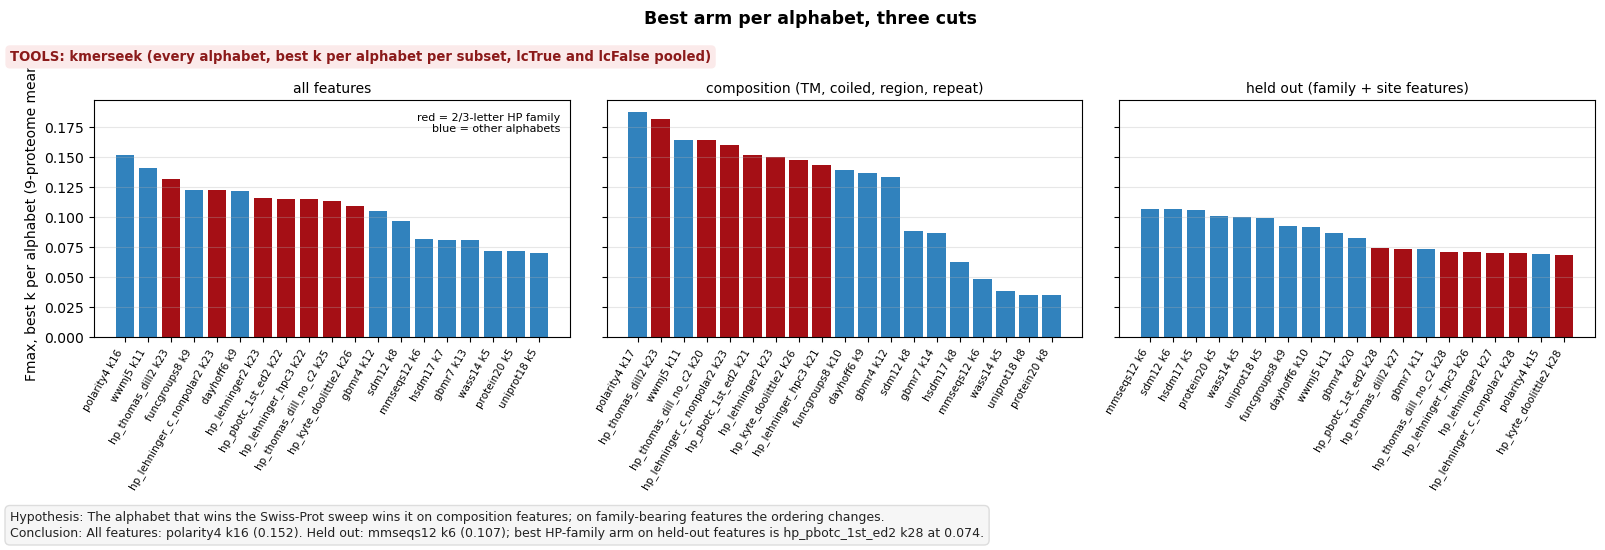

In [6]:
km = mean.filter(pl.col("tool") == "kmerseek").with_columns(
    pl.col("variant").str.extract(r"^(.+)_k\d+", 1).alias("alphabet"),
    pl.col("variant").str.extract(r"_k(\d+)", 1).cast(pl.Int64).alias("k"),
)
top5 = (
    km.sort("subset", "fmax", descending=[False, True])
    .group_by("subset", maintain_order=True)
    .head(5)
)
print(top5.select("subset", "variant", pl.col("fmax").round(3)))
per_alpha = (
    km.sort("fmax", descending=True)
    .group_by("subset", "alphabet")
    .first()
    .sort("subset", "fmax", descending=[False, True])
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for ax, s in zip(axes, ["all", "composition", "heldout"]):
    t = per_alpha.filter(pl.col("subset") == s)
    cols = ["#a50f15" if a.startswith("hp_") else "#3182bd" for a in t["alphabet"]]
    ax.bar(np.arange(t.height), t["fmax"], color=cols)
    ax.set_xticks(
        np.arange(t.height),
        [f"{a} k{k}" for a, k in zip(t["alphabet"], t["k"])],
        rotation=60,
        ha="right",
        fontsize=7.5,
    )
    ax.set_title(SUBSET_LABEL[s].replace("\n", " "), fontsize=10)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Fmax, best k per alphabet (9-proteome mean)")
axes[0].text(
    0.98,
    0.95,
    "red = 2/3-letter HP family\nblue = other alphabets",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=8,
)

best_hp_held = (
    per_alpha.filter(
        (pl.col("subset") == "heldout") & pl.col("alphabet").str.starts_with("hp_")
    )
    .sort("fmax", descending=True)
    .row(0, named=True)
)
best_held = per_alpha.filter(pl.col("subset") == "heldout").row(0, named=True)
best_all = per_alpha.filter(pl.col("subset") == "all").row(0, named=True)
hc.finish_figure(
    fig,
    FIG / "231_alphabet_winners_by_subset.png",
    tools="kmerseek (every alphabet, best k per alphabet per subset, lcTrue and lcFalse pooled)",
    hypothesis="The alphabet that wins the Swiss-Prot sweep wins it on composition features; on family-bearing features the ordering changes.",
    conclusion=(
        f"All features: {best_all['alphabet']} k{best_all['k']} ({best_all['fmax']:.3f}). Held out: {best_held['alphabet']} k{best_held['k']} ({best_held['fmax']:.3f}); "
        f"best HP-family arm on held-out features is {best_hp_held['alphabet']} k{best_hp_held['k']} at {best_hp_held['fmax']:.3f}."
    ),
    title="Best arm per alphabet, three cuts",
)

## 6. Conclusions

1. The Swiss-Prot standing is a transmembrane result. With TRANSMEM, INTRAMEM, COILED,
   REGION and REPEAT held out, kmerseek's best arm falls from rank 3 of 10 to rank 10 of
   10, at less than half the Fmax of the next tool. On domain-naming range features it is
   also last.
2. A Kyte-Doolittle window, which searches nothing, out-scores every one of the 406
   kmerseek arms on the report's headline Swiss-Prot metric, and reaches 0.78 on TRANSMEM
   where kmerseek's best arm reaches 0.50. The divergence-retention figure on Swiss-Prot is
   a hydrophobicity scan: the 2-letter arm's E. coli/mouse retention is high on composition
   features and collapses on held-out ones, where phmmer keeps more of its mouse score.
3. The 2-letter arm is a REGION-and-TRANSMEM detector. For hp_thomas_dill2 k23, 46% of
   true positives are Swiss-Prot REGION features and 19% TRANSMEM; DOMAIN is 7%. For
   polarity4 k17, TRANSMEM alone is 69%. phmmer's are 35% DOMAIN and 4% TRANSMEM.
4. The alphabet ranking in the report is a ranking on TRANSMEM helices. On family-bearing
   features the best kmerseek arms are the 12- and 17-letter alphabets at k=5-6, and the
   HP family is far down.
5. What to say instead: the Swiss-Prot truth set is a good benchmark for feature types
   that are families or sites, and a composition scan is the right null for the others.
   Any Swiss-Prot number in the paper should be reported on the held-out subset, with the
   scan on the leaderboard.